## Week 6 Day 1
- •	K-Means: centroid update algorithm  implement from scratch in NumPy
- •	Elbow method + silhouette score, find the right K on a customer dataset
- •	Visualise clusters with PCA to 2D: plot and interpret


# K-means
1. Step 1: Identify number of clusters : number of K   (for example k = 3)
2. Step 2: Randomly select 3 distinct data points
3. Step 3: Measure the distance from 1st point to the initial three clusters
4. Step 4: Assign the points to the nearest clusters 1st point to 1st cluster as it is closer to it.
5. Step 5: Calculate the mean of each cluster. Measure points and cluster them using mean values
- Assess the quality of clustering by adding up variation within each cluster
- Start again from beginning and pick new 3 initial clusters and cluster all remaining points.Claculate mean and repeat until clusters no longer change.

## Select value of K
- when we have 3 clear clusters we select  K=3
- But at times it's not easy to identify K: if we plot the reduction in variance per value for K we can see the elbow and select K.

- K-Means: assumes spherical clusters, uses Euclidean distance
- Fails on: crescents, spirals, varying densities
- DBSCAN: handles arbitrary shapes

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Roadmap/Datasets/Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print(X.shape)

(200, 2)


## Task -1
1.	K-Means -> centroid update algorithm: implement from scratch in NumPy
- -->>>
- STep 1: Initialise -> Randomly pick K points as centroids
- Step 2: Assign -> assign each point to nearest centroid
- Step 3: Update -> move centroid to mean of assigned points
- Step 4: Check convergence -> Check and stop when centroids dont move


In [8]:
def kmeans(X,k, max_iters = 100):
  # STep 1: randomly initialise k centroids
  idx = np.random.choice(len(X),k, replace=False)
  centroids = X[idx]


  #Step 2: Assign each point to nearest centroid
  for _ in range(max_iters):
    labels = np.array([
        np.argmin([np.linalg.norm(x-c) for c in centroids])
        for x in X
    ])

    #step 3: update centroids
    new_centroids = np.array( [X[labels == i].mean(axis = 0) for i in range(k)
      ])

    # Step 4: Convergence
    if np.allclose(centroids, new_centroids):
      break

    centroids = new_centroids
  return labels, centroids


In [10]:
def kmeans(X,k,max_iters = 100):
  #Step 1: randomly initialise k centroids

  idx = np.random.choice(len(X), k, replace=False)  # pick k random indices from len(X), no replacement

  centroids = X[idx] #grab those rows from X

  for _ in range(max_iters):
    #----------------------------------------------
    #STEP 2: Assign each point to centroids
    #---------------------------------------

   labels = np.array([
       np.argmin([np.linalg.norm(x - c) for c in centroids])
                     for x in X
                      ])


    #----------------------------------------------
    #STEP 3: update centroids
    #---------------------------------------

   new_centroids = np.array([
        X[labels == i].mean(axis=0)  for i in range(k)
      ])

   ##----------------------------------------------
   #STEP 4: Converge
   # if centroids haven't moved stop
   #---------------------------------------
   if np.allclose(centroids, new_centroids):
    break
   centroids = new_centroids

  return labels, centroids



In [11]:
labels, centroids = kmeans(X, k=5)
print(labels[:10])
print(centroids)

[2 4 2 4 2 4 2 4 2 4]
[[86.53846154 82.12820513]
 [55.5        49.375     ]
 [26.30434783 20.91304348]
 [88.2        17.11428571]
 [26.30434783 78.56521739]]


1. Centroid 0: Income=87, Spending=82  → high income, high spending
2. Centroid 1: Income=56, Spending=49  → middle everything
3. Centroid 2: Income=26, Spending=21  → low income, low spending
4. Centroid 3: Income=88, Spending=17  → high income, low spending
5. Centroid 4: Income=26, Spending=79  → low income, high spending

In [12]:
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(39), np.int64(1): np.int64(80), np.int64(2): np.int64(23), np.int64(3): np.int64(35), np.int64(4): np.int64(23)}


## Task - 2
1.•	Elbow method + silhouette score: find the right K on a customer dataset

- Elbow method.
- Loop K from 1 to 10, calculate inertia (sum of squared distances from each point to its centroid)
- plot it

In [14]:
inertia = sum(
    np.linalg.norm(X[i] - centroids[labels[i]]) ** 2
    for i in range(len(X))
)
print(inertia)

44537.16153049848


In [18]:
inertia_value = []

for K in range(1,11):
  labels, centroids = kmeans(X, k=K)

  # calculate inertia
  inertia_ = sum(
      np.linalg.norm(X[i] - centroids[labels[i]]) ** 2
      for i in range(len(X))
  )
  inertia_value.append(inertia_)

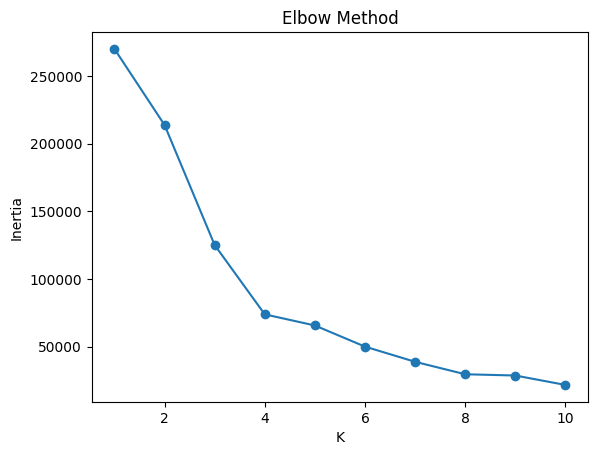

In [19]:
import matplotlib.pyplot as plt


plt.plot(range(1,11), inertia_value, marker = 'o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

###Silhouette score measures how similar a point is to its own cluster vs other clusters. Range is -1 to 1:

1. Close to 1 → point well matched to its cluster
2. Close to 0 → point on boundary between clusters
3. Negative → point might be in wrong cluster

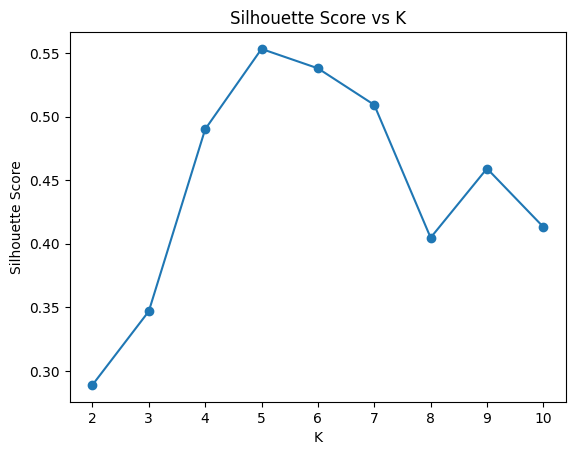

In [20]:
from sklearn.metrics import silhouette_score

# calculate for K=2 to 10 (silhouette needs at least 2 clusters)

sill_scores = []
for K in range(2,11):
  labels,centroids = kmeans(X,k = K)
  score = silhouette_score(X, labels)
  sill_scores.append(score)

plt.plot(range(2,11), sill_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

## Task 4	-
1. Visualise clusters with PCA to 2D : plot and interpret

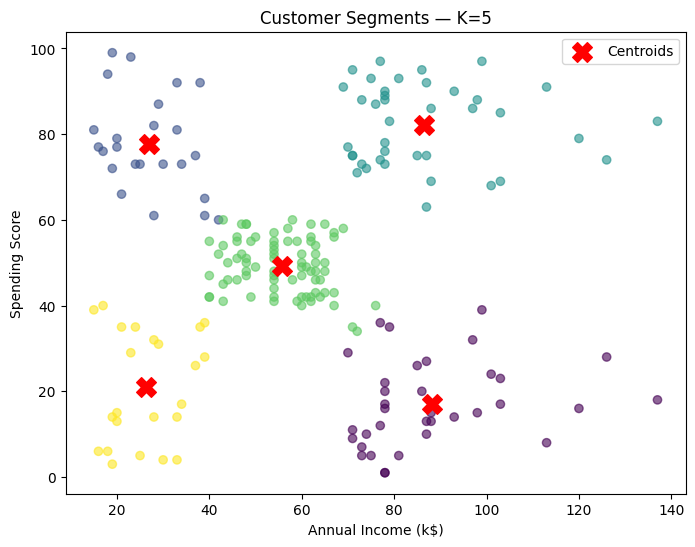

In [21]:
labels, centroids = kmeans(X, k=5)

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segments — K=5')
plt.legend()
plt.show()


## Week 6 Day 1: K-Means Clustering

### Algorithm (from scratch)
1. Initialise K random centroids
2. Assign each point to nearest centroid (Euclidean distance)
3. Update centroids to mean of assigned points
4. Repeat until convergence (np.allclose)

### Choosing K
- Elbow method: plot inertia vs K, find bend → K=5
- Silhouette score: plot score vs K, find peak → K=5
- Both methods agreed on K=5

### Customer Segments Found
- Low income, high spending → impulsive spenders
- Low income, low spending → budget customers  
- Medium everything → average customers
- High income, high spending → premium targets 🎯
- High income, low spending → careful high earners

### K-Means limitations
- Assumes spherical clusters
- Sensitive to initialisation
- Must specify K in advance